In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
df_train = pd.read_csv("/content/fer2013_data/train.csv")
df_test = pd.read_csv("/content/fer2013_data/test.csv")

In [40]:
df_train.head()


,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [41]:
df_test.head()

,pixels
0,254 254 254 254 254 249 255 160 2 58 53 70 77 ...
1,156 184 198 202 204 207 210 212 213 214 215 21...
2,69 118 61 60 96 121 103 87 103 88 70 90 115 12...
3,205 203 236 157 83 158 120 116 94 86 155 180 2...
4,87 79 74 66 74 96 77 80 80 84 83 89 102 91 84 ...


In [42]:
df_train.shape

(28709, 2)

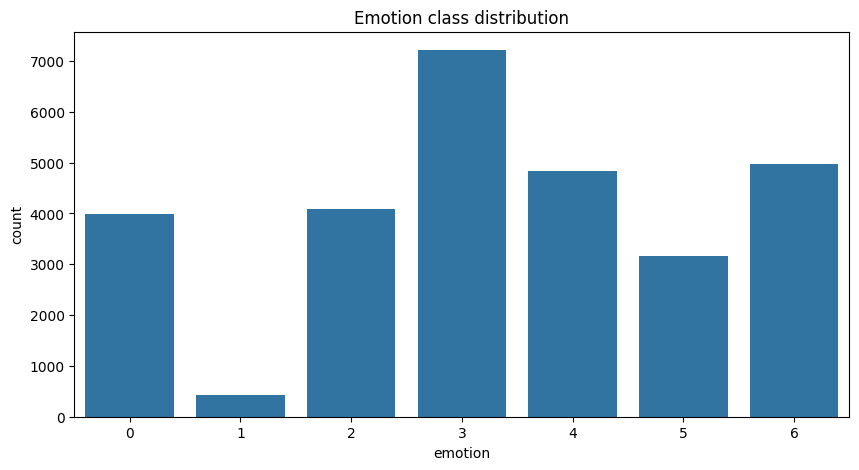

In [43]:
plt.figure(figsize=(10,5))
sns.countplot(x=df_train["emotion"])
plt.title("Emotion class distribution")
plt.show()

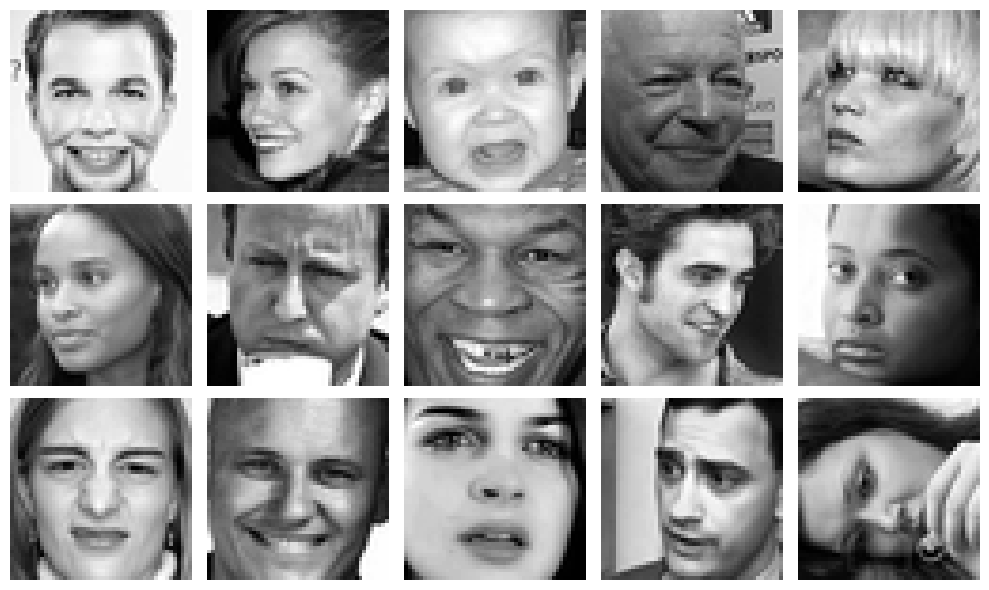

In [44]:
def row_to_image(row):
   img = np.fromstring(row, sep=' ', dtype=np.uint8)
   return img.reshape(48, 48)

fig, axes = plt.subplots(3, 5, figsize=(10,6))

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(df_train))

    img = row_to_image(df_train.iloc[idx]["pixels"])
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [45]:
pixels = np.stack(df_train["pixels"].apply(lambda x : np.fromstring(x, sep=' ', dtype=np.uint8)))
print("Pixels mean: ", pixels.mean())
print("Pixels std: ", pixels.std())

Pixels mean:  129.47433955331468
Pixels std:  65.02727348443116


In [46]:
from sklearn.model_selection import train_test_split

y = df_train["emotion"]
X = df_train["pixels"]

X_train, X_val, y_train, y_val = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)


In [47]:
print(X_train.shape)
print(X_val.shape)

(22967,)
(5742,)


In [48]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class FERDataset(Dataset):
  def __init__(self, X, y):
    self.X = X.reset_index(drop=True)
    self.y = y.reset_index(drop=True)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    pixels = np.fromstring(self.X.iloc[idx], sep=' ', dtype=np.uint8)
    img = pixels.reshape(48, 48)
    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0
    label = torch.tensor(self.y.iloc[idx], dtype=torch.long)
    return img, label

In [49]:

train_dataset = FERDataset(X_train, y_train)
val_dataset = FERDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


In [50]:
train_split = pd.DataFrame({
    "pixels": X_train,
    "emotion": y_train
})

val_split = pd.DataFrame({
    "pixels": X_val,
    "emotion": y_val
})



In [ ]:
import os
os.makedirs("data", exist_ok=True)

train_split.to_csv("data/train_split.csv", index=False)
val_split.to_csv("data/val_split.csv", index=False)